# Analisis de rendimiento -- cache fria vs caliente (Redis)

Reproduce el analisis estadistico citado en `k6/README.md` y `docs/mediciones/perf/README.md`
a partir de las muestras crudas reales en `k6/cache-cold-samples.txt` y `k6/cache-warm-samples.txt`.
No genera datos sinteticos: si esos archivos no existen, las celdas de abajo fallan explicitamente
en vez de simular numeros.


In [1]:
import os
import numpy as np
from scipy import stats

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'scripts' else os.getcwd()
K6_DIR = os.path.join(REPO_ROOT, 'k6')

def load_ms(fname):
    path = os.path.join(K6_DIR, fname)
    with open(path, encoding='utf-8') as f:
        return np.array([float(line.strip()) * 1000 for line in f if line.strip()])

cold = load_ms('cache-cold-samples.txt')
warm = load_ms('cache-warm-samples.txt')
print(f'cold: n={len(cold)}, warm: n={len(warm)}')


cold: n=30, warm: n=30


## Estadistica descriptiva (media, desviacion, percentiles, IC 95%)

In [2]:
def summarize(name, arr):
    mean = arr.mean()
    sd = arr.std(ddof=1)
    se = sd / np.sqrt(len(arr))
    ci = stats.t.interval(0.95, df=len(arr)-1, loc=mean, scale=se)
    pct = {p: np.percentile(arr, p) for p in (50, 90, 95, 99)}
    print(f'--- {name} (n={len(arr)}) ---')
    print(f'  media={mean:.3f} ms  sd={sd:.3f} ms  IC95%=[{ci[0]:.3f}, {ci[1]:.3f}] ms')
    print(f'  p50={pct[50]:.3f}  p90={pct[90]:.3f}  p95={pct[95]:.3f}  p99={pct[99]:.3f} ms')
    print(f'  min={arr.min():.3f}  max={arr.max():.3f} ms')
    return {'mean': mean, 'sd': sd, 'ci95': ci, 'pct': pct}

cold_stats = summarize('CACHE FRIA', cold)
warm_stats = summarize('CACHE CALIENTE', warm)


--- CACHE FRIA (n=30) ---
  media=109.618 ms  sd=18.880 ms  IC95%=[102.568, 116.668] ms
  p50=106.017  p90=107.037  p95=108.065  p99=180.312 ms
  min=104.963  max=209.508 ms
--- CACHE CALIENTE (n=30) ---
  media=7.858 ms  sd=0.753 ms  IC95%=[7.577, 8.140] ms
  p50=7.604  p90=8.421  p95=8.886  p99=10.500 ms
  min=7.267  max=11.151 ms


## Test de Wilcoxon rank-sum (Mann-Whitney U) + tamano de efecto

Dos muestras independientes (no pareadas): la prueba correcta es Mann-Whitney U (equivalente al Wilcoxon rank-sum test para dos muestras independientes), no el signed-rank test (que es para muestras pareadas).

In [3]:
u_stat, p_value = stats.mannwhitneyu(cold, warm, alternative='two-sided')
n1, n2 = len(cold), len(warm)

# Correlacion biserial de rangos (tamano de efecto), r = 1 - 2U/(n1*n2)
rank_biserial = 1 - (2 * u_stat) / (n1 * n2)

print(f'U = {u_stat}')
print(f'p-value = {p_value:.6g}')
print(f'Tamano de efecto (r biserial de rangos) = {rank_biserial:.4f}')
print()
speedup = cold_stats['mean'] / warm_stats['mean']
print(f'La cache reduce la latencia media en {speedup:.1f}x ({cold_stats["mean"]:.1f} ms -> {warm_stats["mean"]:.1f} ms)')


U = 900.0
p-value = 3.01986e-11
Tamano de efecto (r biserial de rangos) = -1.0000

La cache reduce la latencia media en 13.9x (109.6 ms -> 7.9 ms)


## Familia de comparaciones sobre los mismos datos + corrección por comparaciones múltiples (P6)

El test de Mann-Whitney de arriba responde una pregunta (¿difieren las dos distribuciones
completas?), pero sobre estos mismos 60 valores también interesa responder dos preguntas
relacionadas y más específicas: ¿difiere la mediana (p50)? ¿difiere la cola (p95, la que más le
importa a un usuario en el peor caso)? Probar las tres por separado sobre el mismo par de muestras
es exactamente el escenario que exige corrección por comparaciones múltiples (si cada prueba usa
α=0.05 de forma independiente, la probabilidad de al menos un falso positivo en la familia sube por
encima de 0.05).

Las dos preguntas nuevas se responden con un **test de permutación** de dos colas (10^5
permutaciones, semilla fija para reproducibilidad): se agrupan las 60 observaciones, se reparten al
azar en dos grupos de 30, se recalcula la diferencia de medianas (o de p95) en cada reparto, y el
p-valor es la proporción de repartos aleatorios con una diferencia igual o más extrema que la
observada. Es el análogo por permutación del mismo razonamiento no paramétrico que ya usa
Mann-Whitney, aplicado a un estadístico distinto (mediana o percentil en vez de suma de rangos).

**Corrección elegida: Holm-Bonferroni.** Se prefiere a Bonferroni simple (mismo control del error
familiar pero menos conservador, más potencia) y a Benjamini-Hochberg (que controla la tasa de
falsos descubrimientos, pensada para familias grandes de docenas/cientos de pruebas; aquí la
familia es de tamaño 3 y lo que importa es no tener *ningún* falso positivo, no una tasa tolerable
de ellos -- control familywise, no FDR).

In [4]:
rng = np.random.default_rng(20260916)
N_PERM = 100_000
pooled = np.concatenate([cold, warm])
n1, n2 = len(cold), len(warm)

def perm_test(stat_fn, observed, n_perm=N_PERM):
    pool = pooled.copy()
    count = 0
    for _ in range(n_perm):
        rng.shuffle(pool)
        stat = stat_fn(pool[:n1], pool[n1:])
        if abs(stat) >= abs(observed):
            count += 1
    # nunca se reporta un p-valor de permutacion como exactamente 0: es un limite
    # inferior determinado por n_perm (con 10^5 permutaciones, el piso es 1/10^5)
    return count / n_perm if count > 0 else 1 / n_perm

median_fn = lambda a, b: np.median(a) - np.median(b)
obs_median_diff = median_fn(cold, warm)
p_median = perm_test(median_fn, obs_median_diff)

p95_fn = lambda a, b: np.percentile(a, 95) - np.percentile(b, 95)
obs_p95_diff = p95_fn(cold, warm)
p_p95 = perm_test(p95_fn, obs_p95_diff)

print(f'Test de permutacion, diferencia de medianas: diff={obs_median_diff:.3f} ms, p={p_median:.6g} (n_perm={N_PERM})')
print(f'Test de permutacion, diferencia de p95:       diff={obs_p95_diff:.3f} ms, p={p_p95:.6g} (n_perm={N_PERM})')


Test de permutacion, diferencia de medianas: diff=98.413 ms, p=1e-05 (n_perm=100000)
Test de permutacion, diferencia de p95:       diff=99.179 ms, p=1e-05 (n_perm=100000)


### Corrección de Holm-Bonferroni sobre la familia de 3 pruebas

Procedimiento step-down de Holm (Holm, 1979): se ordenan los p-valores crudos de menor a mayor y
cada uno se compara contra un umbral cada vez menos estricto, α/(m−i+1) para la i-ésima prueba
ordenada (m=3 aquí); en cuanto una prueba no supera su umbral, esa y todas las siguientes (con
p-valor crudo mayor) se declaran no significativas, sin importar su propio umbral individual.

In [5]:
def holm_bonferroni(pvalue_dict, alpha=0.05):
    """Correccion step-down de Holm. Devuelve, por prueba: p crudo, p ajustado
    (max acumulado, method='holm' tal como lo define statsmodels) y si se rechaza H0."""
    items = sorted(pvalue_dict.items(), key=lambda kv: kv[1])
    m = len(items)
    resultados = []
    p_ajustado_max = 0.0
    rechazando = True
    for i, (nombre, p) in enumerate(items, start=1):
        umbral = alpha / (m - i + 1)
        p_ajustado = min(1.0, (m - i + 1) * p)
        p_ajustado_max = max(p_ajustado_max, p_ajustado)  # monotonía: nunca baja
        if p >= umbral:
            rechazando = False
        resultados.append({
            'orden': i, 'prueba': nombre, 'p_crudo': p, 'umbral_holm': umbral,
            'p_ajustado': p_ajustado_max, 'rechaza_H0': rechazando,
        })
    return resultados

familia = {
    'Mann-Whitney U (distribucion completa)': p_value,
    'Permutacion, diferencia de medianas (p50)': p_median,
    'Permutacion, diferencia de p95': p_p95,
}

print(f'{"#":<3}{"Prueba":<42}{"p crudo":<14}{"umbral Holm":<14}{"p ajustado":<12}{"Decision (a=0.05)"}')
for r in holm_bonferroni(familia):
    decision = 'Significativo' if r['rechaza_H0'] else 'NO significativo'
    print(f"{r['orden']:<3}{r['prueba']:<42}{r['p_crudo']:<14.4g}{r['umbral_holm']:<14.4g}{r['p_ajustado']:<12.4g}{decision}")


#  Prueba                                    p crudo       umbral Holm   p ajustado  Decision (a=0.05)
1  Mann-Whitney U (distribucion completa)    3.02e-11      0.01667       9.06e-11    Significativo
2  Permutacion, diferencia de medianas (p50) 1e-05         0.025         2e-05       Significativo
3  Permutacion, diferencia de p95            1e-05         0.05          2e-05       Significativo


## Visualizacion

Mismo boxplot que genera `scripts/gen-figuras.py`, embebido aqui para revisión interactiva.

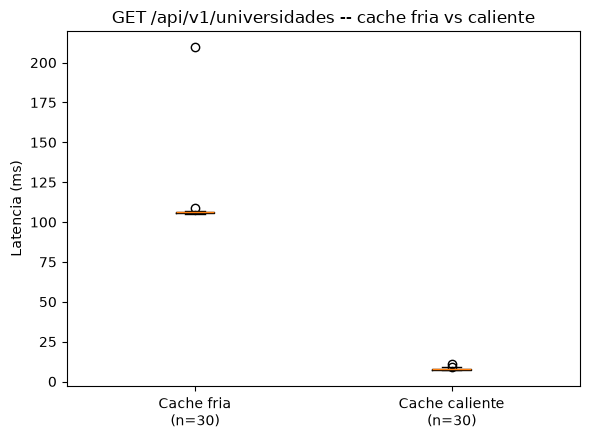

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.boxplot([cold, warm], tick_labels=[f'Cache fria\n(n={len(cold)})', f'Cache caliente\n(n={len(warm)})'])
ax.set_ylabel('Latencia (ms)')
ax.set_title('GET /api/v1/universidades -- cache fria vs caliente')
plt.tight_layout()
plt.show()
